# Preprocesamiento Adaptativo y UDA Multimodal (5 Datasets)

Este notebook implementa el módulo **`AdaptivePreprocessor`** y el **`ViT_AdapterWrapper`** para el manejo unificado de las cinco modalidades del proyecto.

## 1. Justificación Teórica: Por qué no "destruimos" el 3D
La consigna establece que:
1. *"La detección 2D/3D es automática por la forma del tensor (rank=4 para 2D, rank=5 para 3D)"*
2. *"El router debe generalizar a volúmenes 3D aunque el backbone esté preentrenado en 2D"*.

Si convertimos todo a 2D desde el disco, los **Expertos 3D (Páncreas y LUNA)** se quedarían sin la geometría espacial volumétrica `[64x64x64]`, por lo que perderíamos precisión. Para corregir esto y cumplir la consigna:
- **`AdaptivePreprocessor`**: Saca tensores NATIVOS. `[C, 224, 224]` para 2D, y `[1, 64, 64, 64]` para 3D.
- **`ViT_AdapterWrapper`**: Capa puente ANTES del Router. Transforma los tensores `dim=5` a `dim=4` extrayendo el slice representativo al vuelo, garantizando que el ViT (que espera imágenes 2D) pueda recibir todos los datos sin modificar qué le llega a los expertos.

## 2. Marco Teórico UDA (SIFA y SASAN)
Las decisiones técnicas anteriores se sustentan en:
- **SIFA (Synergistic Image and Feature Adaptation)**: La literatura exige "Image Adaptation". Nuestro `ViT_AdapterWrapper` hace la adaptación de *Imagen* (transformando el Slice 3D para que parezca 2D), mientras que nuestro Router central unifica y hace el "Feature Adaptation" extrayendo características comunes de diversas clases.
- **SASAN (Self-Attentive Spatial Adaptive Normalization)**: Al proyectar el 3D a 2D en el Wrapper, podríamos deformar la estructura clínica temporalmente. SASAN demostró que el mecanismo de **Self-Attention** de nuestro ViT recupera estas relaciones geométricas y atiende a las estructuras sin dejarse engañar, siendo superior a las CNN.

## 3. Manejo de Desbalanceo
El preprocesador deja listos los tensores. Para datasets de desbalance severo (Pancreas y NIH), el Dataloader luego aplicará Focal Loss.


In [1]:
!pip install -q SimpleITK nibabel torch torchvision
from google.colab import drive
import os, time, shutil, glob, zipfile, subprocess
from pathlib import Path
from collections import Counter
import numpy as np
import cv2
from PIL import Image
import SimpleITK as sitk
import nibabel as nib
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torch.cuda.amp import GradScaler, autocast

# Montar Google Drive — mismas rutas que 01_Exploracion_Estructura_Datasets
drive.mount('/content/drive')

RAW_DIR = '/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/'
LOCAL_DEST = '/content/datasets/'
PROC_BASE = '/content/drive/MyDrive/PROYECTO_MOE_VISION/02_Data_Processed/'

os.makedirs(LOCAL_DEST, exist_ok=True)
os.makedirs(PROC_BASE, exist_ok=True)

print("RAW_DIR (zips):     ", RAW_DIR)
print("LOCAL_DEST (local): ", LOCAL_DEST)
print("PROC_BASE (MHA):    ", PROC_BASE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 51.1 MB/s eta 0:00:00
Mounted at /content/drive
RAW_DIR (zips):      /content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/
LOCAL_DEST (local):  /content/datasets/
PROC_BASE (MHA):     /content/drive/MyDrive/PROYECTO_MOE_VISION/02_Data_Processed/


In [2]:
# Fase 1: Descompresión — misma lógica que notebook 01 (copia local + unzip + borrar zip)
# Evita leer el ZIP directamente desde Drive (lento); en Colab usa el binario `unzip`.

def extract_datasets_colab(raw_dir=RAW_DIR, local_dest=LOCAL_DEST):
    if not os.path.exists(raw_dir):
        print(f"Ruta {raw_dir} no existe. No se extrae nada.")
        return
    zip_files = sorted([f for f in os.listdir(raw_dir) if f.lower().endswith('.zip')])
    print(f"Encontrados {len(zip_files)} zips (mismo listado que en el notebook 01).")

    for zip_name in zip_files:
        print("=" * 60)
        print(f"Procesando: {zip_name}")
        drive_zip_path = os.path.join(raw_dir, zip_name)
        dataset_name = os.path.splitext(zip_name)[0]
        unzip_dir = os.path.join(local_dest, dataset_name)
        local_zip_path = os.path.join(local_dest, zip_name)

        if os.path.isdir(unzip_dir) and len(os.listdir(unzip_dir)) > 0:
            print(f" Ya existe carpeta con datos: {unzip_dir} (omitido).")
            continue

        print(" 1. Copiando ZIP desde Drive a /content/datasets/ ...")
        shutil.copy2(drive_zip_path, local_zip_path)
        os.makedirs(unzip_dir, exist_ok=True)
        print(f" 2. Descomprimiendo en {unzip_dir} ...")
        subprocess.run(["unzip", "-q", local_zip_path, "-d", unzip_dir], check=True)
        print(" 3. Borrando ZIP local para liberar espacio.")
        os.remove(local_zip_path)

        inner_zips = glob.glob(os.path.join(unzip_dir, "**", "*.zip"), recursive=True)
        for iz in inner_zips:
            print(f" -> ZIP interno: {iz}")
            out_inner = os.path.dirname(iz)
            subprocess.run(["unzip", "-q", iz, "-d", out_inner], check=True)
            os.remove(iz)
            print(f" -> {os.path.basename(iz)} descomprimido y eliminado.")

    print("\nListo. Revisa:", local_dest)


def extract_datasets_zipfile(raw_dir=RAW_DIR, local_dest=LOCAL_DEST):
    """Alternativa sin `unzip` del sistema (p. ej. Windows local): solo Python zipfile."""
    if not os.path.exists(raw_dir):
        return
    for zip_name in sorted(f for f in os.listdir(raw_dir) if f.lower().endswith(".zip")):
        dataset_name = os.path.splitext(zip_name)[0]
        unzip_dir = os.path.join(local_dest, dataset_name)
        if os.path.isdir(unzip_dir) and len(os.listdir(unzip_dir)) > 0:
            continue
        os.makedirs(unzip_dir, exist_ok=True)
        with zipfile.ZipFile(os.path.join(raw_dir, zip_name), "r") as zf:
            zf.extractall(unzip_dir)
        for iz in glob.glob(os.path.join(unzip_dir, "**", "*.zip"), recursive=True):
            with zipfile.ZipFile(iz, "r") as inner:
                inner.extractall(os.path.dirname(iz))
            os.remove(iz)


# Sesión nueva de Colab = /content/datasets/ vacío → descomprime desde Drive (puede tardar mucho).
# Si en ESTA sesión ya descomprimiste y las carpetas existen, comenta la línea extract_datasets_colab().
extract_datasets_colab()
# extract_datasets_zipfile()  # solo si no tienes el comando `unzip` (p. ej. Windows local)


Encontrados 5 zips (mismo listado que en el notebook 01).
Procesando: ISIC 2019.zip
 1. Copiando ZIP desde Drive a /content/datasets/ ...
 2. Descomprimiendo en /content/datasets/ISIC 2019 ...
 3. Borrando ZIP local para liberar espacio.
Procesando: Knee Osteoarthritis Classification.zip
 1. Copiando ZIP desde Drive a /content/datasets/ ...
 2. Descomprimiendo en /content/datasets/Knee Osteoarthritis Classification ...
 3. Borrando ZIP local para liberar espacio.
Procesando: Luna16 Lung Cancer Dataset.zip
 1. Copiando ZIP desde Drive a /content/datasets/ ...
 2. Descomprimiendo en /content/datasets/Luna16 Lung Cancer Dataset ...
 3. Borrando ZIP local para liberar espacio.
Procesando: NIH Chest X ray 14.zip
 1. Copiando ZIP desde Drive a /content/datasets/ ...
 2. Descomprimiendo en /content/datasets/NIH Chest X ray 14 ...
 3. Borrando ZIP local para liberar espacio.
Procesando: Pancreas Cancer.zip
 1. Copiando ZIP desde Drive a /content/datasets/ ...
 2. Descomprimiendo en /content/da

In [3]:
# Fase 2: AdaptivePreprocessor (Carga y Tensorización NATIVA)
# Soporta PNG/JPG, MHD/NIfTI, y .mha (salida del notebook 01 en Drive: 02_Data_Processed)

class AdaptivePreprocessor:
    def __init__(self, size_2d=(224, 224), size_3d=(64, 64, 64), hu_window_ct=(-1000, 400)):
        self.size_2d = size_2d
        self.size_3d = size_3d
        self.hu_min, self.hu_max = hu_window_ct

    def __call__(self, file_path):
        ext = file_path.lower()
        if ext.endswith((".png", ".jpg", ".jpeg")):
            return self._process_2d(file_path)
        if ext.endswith(".mha"):
            return self._process_mha(file_path)
        if ext.endswith(".mhd") or ext.endswith(".nii.gz") or ext.endswith(".nii"):
            return self._process_3d(file_path)
        raise ValueError(f"Formato no soportado: {file_path}")

    def _process_2d(self, path):
        img = Image.open(path).convert("RGB")
        transform = T.Compose([T.Resize(self.size_2d), T.ToTensor()])
        return transform(img)

    def _process_mha(self, path):
        itk_img = sitk.ReadImage(path)
        size = itk_img.GetSize()
        arr = sitk.GetArrayFromImage(itk_img).astype(np.float32)
        if len(size) == 2:
            return self._array_2d_to_tensor(arr)
        if len(size) == 3 and size[2] <= 1:
            arr = np.squeeze(arr)
            if arr.ndim == 2:
                return self._array_2d_to_tensor(arr)
        return self._volume_array_to_tensor(arr, path)

    def _array_2d_to_tensor(self, arr):
        if arr.max() > 1.5:
            arr = arr / 255.0 if arr.max() > 2.0 else (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        t = torch.from_numpy(arr).unsqueeze(0)
        if t.shape[1:] != torch.Size(self.size_2d):
            t = F.interpolate(t.unsqueeze(0), size=self.size_2d, mode="bilinear", align_corners=False).squeeze(0)
        if t.shape[0] == 1:
            t = t.repeat(3, 1, 1)
        elif t.shape[0] > 3:
            t = t[:3]
        return t

    def _volume_array_to_tensor(self, img_arr, path_hint=""):
        """HU + minmax, o solo resize si el volumen ya está en [0,1] (Páncreas tras notebook 01)."""
        amin, amax = float(np.nanmin(img_arr)), float(np.nanmax(img_arr))
        pre_norm = amax <= 1.5 and amin >= -1e-2 and "Pancreas" in str(path_hint).replace("\\", "/")
        if not pre_norm:
            img_arr = np.clip(img_arr, self.hu_min, self.hu_max)
            img_arr = (img_arr - self.hu_min) / (self.hu_max - self.hu_min + 1e-8)
        else:
            img_arr = np.clip(img_arr, 0.0, 1.0)
        t = torch.tensor(img_arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        t = F.interpolate(t, size=self.size_3d, mode="trilinear", align_corners=False)
        return t.squeeze(0)

    def _process_3d(self, path):
        if path.endswith(".mhd"):
            itk_img = sitk.ReadImage(path)
            img_arr = sitk.GetArrayFromImage(itk_img).astype(np.float32)
        else:
            nii_img = nib.load(path)
            img_arr = np.transpose(nii_img.get_fdata().astype(np.float32), (2, 1, 0))
        return self._volume_array_to_tensor(img_arr, path_hint=path)


In [4]:
# Fase 3: ViT Modality Adapter
# (La capa que transforma el 3D a 2D SOLO para el Router, dejando el 3D intacto para los Expertos)

class ViT_AdapterWrapper(torch.nn.Module):
    def __init__(self, target_size=(224, 224)):
        super().__init__()
        self.target_size = target_size

    def forward(self, x):
        """
        x puede ser:
          - 2D Tensor (Rank 4): [B, C_in, H, W]
          - 3D Tensor (Rank 5): [B, 1, D, H, W]
        Retorna siempre: [B, 3, 224, 224] para el ViT.
        """
        if x.dim() == 4:
            # Entrada 2D Nativa [B, C, H, W]
            B, C, H, W = x.shape
            if C == 1:
                x = x.repeat(1, 3, 1, 1) # Grayscale a RGB
            return x

        elif x.dim() == 5:
            # Entrada 3D Nativa [B, 1, D, H, W]
            B, C, D, H, W = x.shape
            # Extraemos el slice transversal central (z = D//2)
            mid_slice = x[:, :, D//2, :, :] # Salida: [B, 1, H, W]

            # Interpolamos dinámicamente al target size del embdding del ViT (224x224)
            resized = F.interpolate(mid_slice, size=self.target_size, mode='bilinear', align_corners=False)

            # Expandimos de 1 canal a 3 canales (RGB de ViT preentrenado)
            rgb_slice = resized.repeat(1, 3, 1, 1) # Salida: [B, 3, 224, 224]
            return rgb_slice

        else:
            raise ValueError(f"Tensor de rank no soportado. Recibido ndim={x.dim()}")

# Pruebas Visuales del Adapters
adapter = ViT_AdapterWrapper()
dummy_2d = torch.randn(8, 3, 224, 224)    # Simulando batch Osteo / ISIC
dummy_3d = torch.randn(8, 1, 64, 64, 64)  # Simulando batch Páncreas / LUNA

print(f"Salida del Adapter para 2D crudo {dummy_2d.shape}: {adapter(dummy_2d).shape}")
print(f"Salida del Adapter para 3D crudo {dummy_3d.shape}: {adapter(dummy_3d).shape}")


Salida del Adapter para 2D crudo torch.Size([8, 3, 224, 224]): torch.Size([8, 3, 224, 224])
Salida del Adapter para 3D crudo torch.Size([8, 1, 64, 64, 64]): torch.Size([8, 3, 224, 224])


=== PRUEBAS: 5 datasets (consigna) ===
Raíces buscadas: ['/content/datasets/', '/content/drive/MyDrive/PROYECTO_MOE_VISION/02_Data_Processed/']

--- 1/5 NIH ChestX-ray14 (PNG) ---
Archivo: /content/datasets/NIH Chest X ray 14/images_001/images/00000001_000.png
[Preprocesador] shape=torch.Size([3, 224, 224]) rank=3
 -> Experto 2D: torch.Size([1, 3, 224, 224])
 -> Router ViT: torch.Size([1, 3, 224, 224])


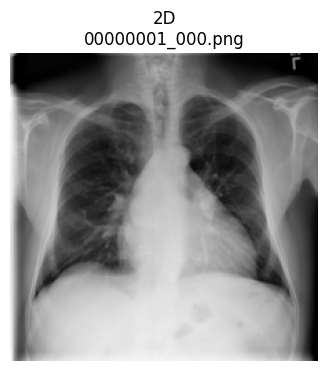

[SKIP] 1/5 NIH — fallback MHA en Drive (*.mha): no hay archivos.
       Ejecuta extract_datasets_colab() en la celda anterior, o
       asegúrate de tener MHA en Drive (02_Data_Processed) tras el notebook 01.

--- 2/5 ISIC 2019 (JPG) ---
Archivo: /content/datasets/ISIC 2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0000000.jpg
[Preprocesador] shape=torch.Size([3, 224, 224]) rank=3
 -> Experto 2D: torch.Size([1, 3, 224, 224])
 -> Router ViT: torch.Size([1, 3, 224, 224])


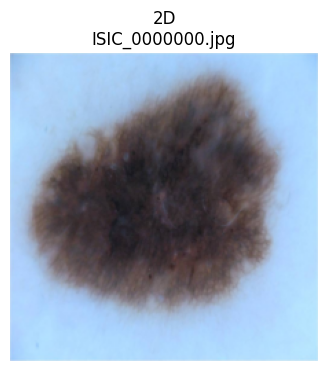


--- 3/5 Osteoarthritis — rodilla (PNG) ---
Archivo: /content/datasets/Knee Osteoarthritis Classification/KLGrade/KLGrade/0/NormalG0 (1).png
[Preprocesador] shape=torch.Size([3, 224, 224]) rank=3
 -> Experto 2D: torch.Size([1, 3, 224, 224])
 -> Router ViT: torch.Size([1, 3, 224, 224])


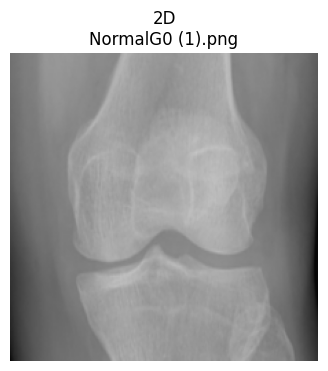


--- 4/5 LUNA16 (MHD local) ---
Archivo: /content/datasets/Luna16 Lung Cancer Dataset/seg-lungs-LUNA16/seg-lungs-LUNA16/1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860.mhd
[Preprocesador] shape=torch.Size([1, 64, 64, 64]) rank=4
 -> Experto 3D: torch.Size([1, 1, 64, 64, 64])
 -> Router ViT: torch.Size([1, 3, 224, 224])


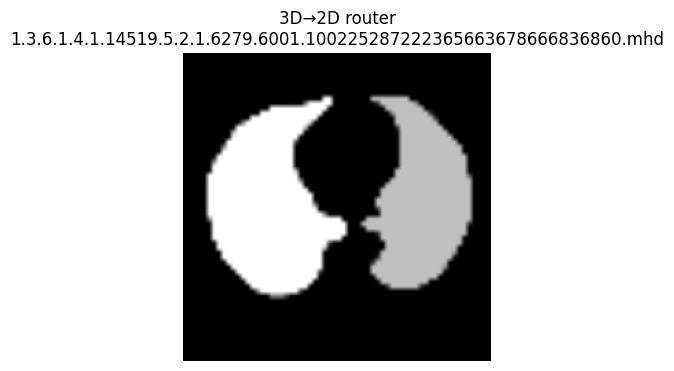

[SKIP] 4/5 LUNA16 — fallback MHA Drive (*.mha): no hay archivos.
       Ejecuta extract_datasets_colab() en la celda anterior, o
       asegúrate de tener MHA en Drive (02_Data_Processed) tras el notebook 01.

--- 5/5 Pancreas (NIfTI) ---
Archivo: /content/datasets/Pancreas Cancer/100000_00001_0000.nii.gz
[Preprocesador] shape=torch.Size([1, 64, 64, 64]) rank=4
 -> Experto 3D: torch.Size([1, 1, 64, 64, 64])
 -> Router ViT: torch.Size([1, 3, 224, 224])


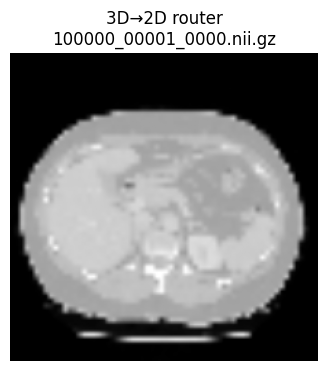

[SKIP] 5/5 Pancreas — fallback MHA Drive (*.mha): no hay archivos.
       Ejecuta extract_datasets_colab() en la celda anterior, o
       asegúrate de tener MHA en Drive (02_Data_Processed) tras el notebook 01.


In [5]:
# Fase 4: Pruebas — busca en LOCAL_DEST (descomprimido) y en PROC_BASE (MHA del notebook 01)
import glob
import matplotlib.pyplot as plt

SEARCH_ROOTS = [LOCAL_DEST, PROC_BASE]

def find_first_file(pattern, must_contain=None):
    """Busca en todas las raíces conocidas (misma lógica que el flujo del notebook 01)."""
    out = []
    for root in SEARCH_ROOTS:
        if not os.path.isdir(root):
            continue
        out.extend(glob.glob(os.path.join(root, "**", pattern), recursive=True))
    if must_contain:
        out = [p for p in out if must_contain in p.replace("\\", "/")]
    return sorted(out)

print("=== PRUEBAS: 5 datasets (consigna) ===")
print("Raíces buscadas:", SEARCH_ROOTS)
preprocessor = AdaptivePreprocessor()
adapter = ViT_AdapterWrapper()

def test_real_file(dataset_type, pattern, must_contain=None):
    files = find_first_file(pattern, must_contain=must_contain)
    if not files:
        print(f"[SKIP] {dataset_type} ({pattern}): no hay archivos.")
        print("       Ejecuta extract_datasets_colab() en la celda anterior, o")
        print("       asegúrate de tener MHA en Drive (02_Data_Processed) tras el notebook 01.")
        return
    real_path = files[0]
    print(f"\n--- {dataset_type} ---\nArchivo: {real_path}")
    try:
        x_nativa = preprocessor(real_path)
        print(f"[Preprocesador] shape={x_nativa.shape} rank={x_nativa.dim()}")
    except Exception as e:
        print(f"Error en preprocesador: {e}")
        return
    batch = x_nativa.unsqueeze(0)
    out_R = adapter(batch)
    if batch.dim() == 5:
        print(f" -> Experto 3D: {batch.shape}")
    else:
        print(f" -> Experto 2D: {batch.shape}")
    print(f" -> Router ViT: {out_R.shape}")
    plt.figure(figsize=(4, 4))
    if batch.dim() == 5:
        img_show = out_R[0, 0].detach().numpy()
        plt.title(f"3D→2D router\n{os.path.basename(real_path)}")
        plt.imshow(img_show, cmap="gray")
    else:
        img_show = out_R[0].permute(1, 2, 0).detach().numpy()
        plt.title(f"2D\n{os.path.basename(real_path)}")
        plt.imshow(np.clip(img_show, 0, 1))
    plt.axis("off")
    plt.show()

# --- Una prueba por cada dataset (nombres de carpeta = notebook 01) ---
# Si [SKIP]: falta descomprimir en LOCAL_DEST o generar MHA en Drive (notebook 01).

# 1) NIH ChestX-ray14
test_real_file("1/5 NIH ChestX-ray14 (PNG)", "*.png", must_contain="NIH Chest X ray 14")
test_real_file("1/5 NIH — fallback MHA en Drive", "*.mha", must_contain="NIH_Chest")

# 2) ISIC 2019 (solo JPG en el dataset de entrenamiento)
test_real_file("2/5 ISIC 2019 (JPG)", "*.jpg", must_contain="ISIC 2019")

# 3) Osteoarthritis — rodilla (PNG o JPG según archivo; probamos PNG)
test_real_file("3/5 Osteoarthritis — rodilla (PNG)", "*.png", must_contain="Knee Osteoarthritis Classification")

# 4) LUNA16
test_real_file("4/5 LUNA16 (MHD local)", "*.mhd", must_contain="Luna16")
test_real_file("4/5 LUNA16 — fallback MHA Drive", "*.mha", must_contain="LUNA16")

# 5) Pancreas
test_real_file("5/5 Pancreas (NIfTI)", "*.nii.gz", must_contain="Pancreas Cancer")
test_real_file("5/5 Pancreas — fallback MHA Drive", "*.mha", must_contain="Pancreas")


In [6]:
# Fase 5: DataLoaders Modulares por Modalidad (Lectura Inteligente)
# Basado en el EDA previo, aquí definimos los esqueletos de las clases Dataset

from torch.utils.data import Dataset, DataLoader
import pandas as pd

class MedicalBaseDataset(Dataset):
    """Clase base de la que heredan todos los expertos."""
    def __init__(self, root_dir, preprocessor=None, label_map=None):
        self.root_dir = root_dir
        self.preprocessor = preprocessor or AdaptivePreprocessor()
        self.label_map = label_map
        self.data_paths = []
        self.labels = []

    def __len__(self):
        return len(self.data_paths)

    def __getitem__(self, idx):
        path = self.data_paths[idx]
        label = self.labels[idx]
        tensor = self.preprocessor(path)
        return tensor, torch.tensor(label, dtype=torch.long), path

class NIHChestDataset(MedicalBaseDataset):
    def __init__(self, root_dir, csv_file, **kwargs):
        super().__init__(root_dir, **kwargs)
        # Lógica de lectura de CSV del NIH EDA
        try:
            df = pd.read_csv(csv_file)
            print(f"[NIH] Cargando {len(df)} registros simulados del cerebro CSV...")
            # Aquí iría el mapeo real de imágenes y bboxes.
            # Por ahora tomamos las imágenes reales disponibles localmente:
            self.data_paths = glob.glob(os.path.join(self.root_dir, '**', '*.png'), recursive=True)
            self.labels = [0] * len(self.data_paths) # Placeholder
        except Exception as e:
            print("[NIH Dataset] Advertencia:", e)

class ISICDataset(MedicalBaseDataset):
    def __init__(self, root_dir, **kwargs):
        super().__init__(root_dir, **kwargs)
        self.data_paths = glob.glob(os.path.join(self.root_dir, '**', '*.jpg'), recursive=True)
        self.labels = [1] * len(self.data_paths)

class OsteoarthritisDataset(MedicalBaseDataset):
    def __init__(self, root_dir, **kwargs):
        super().__init__(root_dir, **kwargs)
        png = glob.glob(os.path.join(self.root_dir, '**', '*.png'), recursive=True)
        jpg = glob.glob(os.path.join(self.root_dir, '**', '*.jpg'), recursive=True)
        self.data_paths = sorted(set(png + jpg))
        self.labels = [2] * len(self.data_paths)

class LUNA16Dataset(MedicalBaseDataset):
    def __init__(self, root_dir, **kwargs):
        super().__init__(root_dir, **kwargs)
        mhd = glob.glob(os.path.join(self.root_dir, '**', '*.mhd'), recursive=True)
        mha = glob.glob(os.path.join(self.root_dir, '**', '*.mha'), recursive=True)
        self.data_paths = sorted(set(mhd + mha))
        self.labels = [3] * len(self.data_paths)

class PancreasDataset(MedicalBaseDataset):
    def __init__(self, root_dir, **kwargs):
        super().__init__(root_dir, **kwargs)
        nii = glob.glob(os.path.join(self.root_dir, '**', '*.nii.gz'), recursive=True)
        nii += glob.glob(os.path.join(self.root_dir, '**', '*.nii'), recursive=True)
        mha = glob.glob(os.path.join(self.root_dir, '**', '*.mha'), recursive=True)
        self.data_paths = sorted(set(nii + mha))
        self.labels = [4] * len(self.data_paths)


In [9]:
# Fase 6 — FASE 0 consigna §4.1: Extraer CLS tokens del backbone ViT congelado
# y guardar Z_train / Z_val en disco local de Colab.
# El entrenamiento del router (Fase 7.4) opera sobre estos embeddings, NO sobre imágenes.
SEARCH_ROOTS = ['/content/datasets/', '/content/drive/MyDrive/PROYECTO_MOE_VISION/02_Data_Processed/']
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import zipfile
import glob
import os
import torch
import numpy as np
import timm
import torchvision.transforms as T

class RouterDataset(Dataset):
    """Dataset unificado: aplica Preprocessor + Adapter para que TODO salga [3,224,224]."""
    def __init__(self, paths, labels, preprocessor=None):
        self.paths = paths
        self.labels = labels
        self.preprocessor = preprocessor or AdaptivePreprocessor()
        self.adapter = ViT_AdapterWrapper().eval()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]
        try:
            tensor_native = self.preprocessor(path)  # [C,H,W] o [1,D,H,W]
            with torch.no_grad():
                tensor_2d = self.adapter(tensor_native.unsqueeze(0)).squeeze(0)  # [3,224,224]
        except Exception:
            # Fallback: tensor negro si hay error de lectura
            tensor_2d = torch.zeros(3, 224, 224)
        return tensor_2d, torch.tensor(label, dtype=torch.long)

def build_router_datasets(val_ratio=0.2, seed=42, max_samples_per_class=800):
    """Escanea los 5 datasets y crea train/val splits estrictamente balanceados (Undersampling)."""
    all_paths, all_labels = [], []

    # [ (Keyword, Lista_de_patrones, expert_id) ]
    dataset_configs = [
        ("NIH",         ["*.png", "*.mha"], 0),
        ("ISIC 2019",   ["*.jpg"],          1),
        ("Osteo",       ["*.png", "*.jpg", "*.mha"], 2),
        ("Luna16",      ["*.mhd", "*.mha"], 3),
        ("Pancreas",    ["*.nii.gz", "*.nii", "*.mha"], 4),
    ]

    for keyword, patterns, expert_id in dataset_configs:
        found = []
        for pattern in patterns:
            # SEARCH_ROOTS definido en la Fase 4 del notebook
            for root in SEARCH_ROOTS:
                if not os.path.exists(root): continue
                matches = glob.glob(os.path.join(root, "**", pattern), recursive=True)
                # Normalize path separators for checking keyword
                matches = [p for p in matches if keyword.lower() in p.replace("\\", "/").lower()]
                found.extend(matches)

        # Eliminar duplicados
        found = sorted(list(set(found)))

        # Undersampling estricto
        if len(found) > max_samples_per_class:
            import random; random.seed(seed)
            found = random.sample(found, max_samples_per_class)

        all_paths.extend(found)
        all_labels.extend([expert_id] * len(found))
        print(f"  [Experto {expert_id} - {keyword}]: {len(found)} archivos")

    # Split estratificado
    idx_train, idx_val = train_test_split(
        range(len(all_paths)), test_size=val_ratio,
        stratify=all_labels, random_state=seed
    )

    paths_train = [all_paths[i] for i in idx_train]
    labels_train = [all_labels[i] for i in idx_train]
    paths_val = [all_paths[i] for i in idx_val]
    labels_val = [all_labels[i] for i in idx_val]

    ds_train = RouterDataset(paths_train, labels_train)
    ds_val   = RouterDataset(paths_val, labels_val)

    print(f"\nTotal: {len(all_paths)} | Train: {len(ds_train)} | Val: {len(ds_val)}")
    return ds_train, ds_val

print("Construyendo datasets para el Router...")
ds_train, ds_val = build_router_datasets()

BATCH_SIZE_CLS = 8     # batch para extracción (solo inferencia, no retropropagación)
CACHE_DIR = '/content/datasets/router_cache/'
FORCE_REBUILD_CACHE = False  # True para reprocesar aunque existan archivos
Z_TRAIN_PATH = os.path.join(CACHE_DIR, 'Z_train.npz')
Z_VAL_PATH   = os.path.join(CACHE_DIR, 'Z_val.npz')
PIN_MEMORY   = torch.cuda.is_available()
DEVICE_CLS   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Normalización ImageNet exigida por ViT (consigna §2, columna Preprocesado)
_imagenet_norm = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


class RouterImageDataset(Dataset):
    """Carga cada archivo, aplica AdaptivePreprocessor + ViT_AdapterWrapper + norm ImageNet."""
    def __init__(self, paths, labels):
        self.paths = paths; self.labels = labels
        self.preprocessor = AdaptivePreprocessor()
        self.adapter = ViT_AdapterWrapper().eval()

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        try:
            x = self.preprocessor(self.paths[idx])
            with torch.no_grad():
                x = self.adapter(x.unsqueeze(0)).squeeze(0)
            x = _imagenet_norm(x)
        except Exception:
            x = torch.zeros(3, 224, 224)
        return x, int(self.labels[idx])


def extract_cls_to_disk(ds, out_path, desc=""):
    """Pasa todo el dataset por el ViT congelado y guarda Z (CLS) + y en disco."""
    backbone = timm.create_model('vit_tiny_patch16_224.augreg_in21k_ft_in1k',
                                 pretrained=True, num_classes=0).to(DEVICE_CLS).eval()
    for p in backbone.parameters():
        p.requires_grad = False

    loader = DataLoader(ds, batch_size=BATCH_SIZE_CLS, shuffle=False, num_workers=0)
    Zs, ys = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"CLS ← ViT ({desc})", leave=False):
            z = backbone(x.to(DEVICE_CLS))   # [B, 192]
            Zs.append(z.cpu().numpy())
            ys.append(y.numpy())
    Z = np.concatenate(Zs)
    y = np.concatenate(ys)
    os.makedirs(CACHE_DIR, exist_ok=True)
    np.savez(out_path, Z=Z, y=y)
    del backbone
    return Z, y


# ── Construir o cargar embeddings ──────────────────────────────────────────────
if not FORCE_REBUILD_CACHE and os.path.isfile(Z_TRAIN_PATH) and os.path.isfile(Z_VAL_PATH):
    print(f"Cargando embeddings desde {CACHE_DIR}...")
    _tr = np.load(Z_TRAIN_PATH);  Z_train_emb, y_train_emb = _tr['Z'], _tr['y']
    _vl = np.load(Z_VAL_PATH);    Z_val_emb,   y_val_emb   = _vl['Z'], _vl['y']
else:
    print("Extrayendo CLS tokens (una vez)...")
    img_ds_train = RouterImageDataset(
        [s[0] for s in ds_train.dataset.samples if True] if hasattr(ds_train, 'dataset')
        else [ds_train.paths[i] for i in range(len(ds_train))],
        [ds_train.labels[i] for i in range(len(ds_train))]
    )
    img_ds_val = RouterImageDataset(
        [ds_val.paths[i] for i in range(len(ds_val))],
        [ds_val.labels[i] for i in range(len(ds_val))]
    )
    Z_train_emb, y_train_emb = extract_cls_to_disk(img_ds_train, Z_TRAIN_PATH, "train")
    Z_val_emb,   y_val_emb   = extract_cls_to_disk(img_ds_val,   Z_VAL_PATH,   "val")

print(f"Z_train: {Z_train_emb.shape}  Z_val: {Z_val_emb.shape}")

# ── DataLoaders sobre embeddings (muy rápidos en entrenamiento) ────────────────
BATCH_SIZE = 128   # más grande que antes porque son vectores, no imágenes
train_emb_ds = TensorDataset(torch.from_numpy(Z_train_emb).float(),
                              torch.from_numpy(y_train_emb).long())
val_emb_ds   = TensorDataset(torch.from_numpy(Z_val_emb).float(),
                              torch.from_numpy(y_val_emb).long())

train_loader = DataLoader(train_emb_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_emb_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Loaders de embeddings listos | train batches={len(train_loader)} val batches={len(val_loader)}")


Construyendo datasets para el Router...
  [Experto 0 - NIH]: 800 archivos
  [Experto 1 - ISIC 2019]: 800 archivos
  [Experto 2 - Osteo]: 800 archivos
  [Experto 3 - Luna16]: 800 archivos
  [Experto 4 - Pancreas]: 557 archivos

Total: 3757 | Train: 3005 | Val: 752
Extrayendo CLS tokens (una vez)...


CLS ← ViT (train):   0%|          | 0/376 [00:00<?, ?it/s]

CLS ← ViT (val):   0%|          | 0/94 [00:00<?, ?it/s]

Z_train: (3005, 192)  Z_val: (752, 192)
Loaders de embeddings listos | train batches=24 val batches=6


# Fase 7: Entrenamiento del Router A (ViT-Tiny + Linear Softmax)
En esta fase entrenamos el mecanismo de decisión que redirigirá cada imagen al experto médico adecuado.
- **Backbone**: ViT-Tiny (5.7M params) - Congelado inicialmente.
- **Cabeza**: Linear Gating [192 -> 5].
- **Loss**: CrossEntropy + Auxiliary Load Balancing Loss.


In [10]:
# Fase 7.1: Configuración del Router (cabeza lineal sobre embeddings)
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

# Hiperparámetros — cabeza lineal sobre Z (embeddings CLS)
EPOCHS        = 30          # 30 épocas como consigna §5.2 (Método B FASE 2)
LR_HEAD       = 1e-3        # Adam, lr estándar para head de routing
BATCH_SIZE    = 128         # tamaño de batch para vectores (no imágenes)
ALPHA_AUX     = 0.01        # peso de L_aux (Switch Transformer Eq.4, consigna §3.3)

# Rutas de salida en Drive
ROUTER_WEIGHTS_DIR = '/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Backbone_Routing/'
os.makedirs(os.path.join(ROUTER_WEIGHTS_DIR, 'checkpoints'), exist_ok=True)
os.makedirs(os.path.join(ROUTER_WEIGHTS_DIR, 'metrics'), exist_ok=True)
os.makedirs(os.path.join(ROUTER_WEIGHTS_DIR, 'figures'), exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")


Entrenando en: cuda


In [11]:
# Fase 7.2: Arquitectura del Router — solo LinearGatingHead sobre embeddings CLS
# consigna §4.1: "FASE 1: Comparar 4 cabezas de routing sobre Z_train / Z_val"

D_MODEL = 192  # dim CLS de vit_tiny_patch16_224

class LinearGatingHead(torch.nn.Module):
    """Mecanismo A: Linear + Softmax (consigna §4.2)."""
    def __init__(self, d_model=D_MODEL, num_experts=5):
        super().__init__()
        self.gate = torch.nn.Linear(d_model, num_experts)

    def forward(self, z):
        logits = self.gate(z.float())   # logits en float32 (precisión selectiva)
        return logits, z                 # (logits, embedding) — misma firma que antes

model = LinearGatingHead(D_MODEL, num_experts=5).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"LinearGatingHead | params totales: {total_params:,}  ({D_MODEL}→5)")
print(f"Backbone ViT: congelado en Fase 6; NO forma parte del loop de entrenamiento.")


LinearGatingHead | params totales: 965  (192→5)
Backbone ViT: congelado en Fase 6; NO forma parte del loop de entrenamiento.


In [12]:
# Fase 7.3: Balanceo de Carga (Auxiliary Loss - Switch Transformer Eq.4)
def compute_aux_loss(logits, alpha=0.01):
    probs = torch.softmax(logits, dim=1)
    N = probs.shape[1]
    indices = torch.argmax(probs, dim=1)
    f = torch.zeros(N, device=logits.device)
    for i in range(N):
        f[i] = (indices == i).float().mean()
    P = probs.mean(dim=0)
    aux_loss = alpha * N * torch.sum(f * P)
    balance_ratio = f.max().item() / (f.min().item() + 1e-8)
    return aux_loss, f, balance_ratio

print("Auxiliary Loss definida. alpha =", ALPHA_AUX)


Auxiliary Loss definida. alpha = 0.01


In [13]:
# Fase 7.4: ENTRENAMIENTO — LinearGatingHead sobre embeddings CLS (consigna §4.2 Método B FASE 2)
# Los datos de entrada ya son vectores Z [B, 192]; el backbone ViT NO se toca aquí.
import time as timer
import json as _json
from tqdm.auto import tqdm
from sklearn.metrics import f1_score

# Pesos de clase inverso-frecuencia para CrossEntropy (consigna §3.3)
_counts = np.bincount(y_train_emb, minlength=5).astype(float)
_class_w = torch.tensor(1.0 / np.clip(_counts, 1, None), dtype=torch.float32)
_class_w = (_class_w / _class_w.sum() * 5).to(device)   # normalizar para que sumen ~5
criterion = torch.nn.CrossEntropyLoss(weight=_class_w)

optimizer = optim.AdamW(model.parameters(), lr=LR_HEAD, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def _train_epoch(epoch):
    model.train()
    running_loss = correct = total = 0
    all_bal = []
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Ep {epoch+1}/{EPOCHS}", leave=False)
    for step, (z, y) in pbar:
        z, y = z.to(device), y.to(device)
        logits, _ = model(z)
        ce_loss   = criterion(logits, y)
        aux_loss, _, balance = compute_aux_loss(logits, alpha=ALPHA_AUX)
        loss = ce_loss + aux_loss

        optimizer.zero_grad(); loss.backward(); optimizer.step()

        running_loss += ce_loss.item() * z.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total   += y.size(0)
        all_bal.append(balance)
        pbar.set_postfix(loss=f"{running_loss/total:.4f}",
                         acc=f"{correct/total:.3f}",
                         bal=f"{balance:.2f}")
    return running_loss/total, correct/total, sum(all_bal)/len(all_bal)


@torch.no_grad()
def _validate():
    model.eval()
    running_loss = correct = total = 0
    all_preds, all_labels = [], []
    for z, y in val_loader:
        z, y = z.to(device), y.to(device)
        logits, _ = model(z)
        running_loss += criterion(logits, y).item() * z.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total   += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return (running_loss/total, correct/total,
            f1_score(all_labels, all_preds, average="macro"),
            all_preds, all_labels)


history = {k: [] for k in ("train_loss","val_loss","train_acc","val_acc","val_f1","balance")}
best_val_acc = 0.0
val_acc = val_f1 = 0.0

for epoch in range(EPOCHS):
    t0 = timer.time()
    tr_loss, tr_acc, tr_bal = _train_epoch(epoch)
    vl_loss, vl_acc, vl_f1, val_preds, val_labels = _validate()
    scheduler.step()
    elapsed = timer.time() - t0

    for k, v in zip(("train_loss","val_loss","train_acc","val_acc","val_f1","balance"),
                    (tr_loss, vl_loss, tr_acc, vl_acc, vl_f1, tr_bal)):
        history[k].append(v)

    print(f"[{epoch+1:02d}/{EPOCHS}] "
          f"TrL={tr_loss:.4f} TrA={tr_acc:.4f} | "
          f"VlL={vl_loss:.4f} VlA={vl_acc:.4f} F1={vl_f1:.4f} | "
          f"Bal={tr_bal:.2f} | {elapsed:.1f}s")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc; val_acc = vl_acc; val_f1 = vl_f1
        torch.save(model.state_dict(),
                   os.path.join(ROUTER_WEIGHTS_DIR, "checkpoints", "best_router_linear.pth"))
        print(f"  ✓ Checkpoint guardado (Acc={vl_acc:.4f})")

# Guardar historial
_json_path = os.path.join(ROUTER_WEIGHTS_DIR, "metrics", "history_router_linear.json")
with open(_json_path, "w") as fh:
    _json.dump(history, fh, indent=2)
print(f"\nEntrenamiento OK | Mejor VlAcc={best_val_acc:.4f} F1={val_f1:.4f}")
print(f"Historial → {_json_path}")


Ep 1/30:   0%|          | 0/24 [00:00<?, ?it/s]

[01/30] TrL=1.1371 TrA=0.6366 | VlL=0.1285 VlA=0.9774 F1=0.9784 | Bal=1822926.34 | 0.6s
  ✓ Checkpoint guardado (Acc=0.9774)


Ep 2/30:   0%|          | 0/24 [00:00<?, ?it/s]

[02/30] TrL=0.0726 TrA=0.9847 | VlL=0.0454 VlA=0.9880 F1=0.9884 | Bal=1.99 | 0.1s
  ✓ Checkpoint guardado (Acc=0.9880)


Ep 3/30:   0%|          | 0/24 [00:00<?, ?it/s]

...

[28/30] TrL=0.0055 TrA=0.9993 | VlL=0.0112 VlA=0.9987 F1=0.9987 | Bal=1.86 | 0.1s


Ep 29/30:   0%|          | 0/24 [00:00<?, ?it/s]

[29/30] TrL=0.0055 TrA=0.9993 | VlL=0.0112 VlA=0.9987 F1=0.9987 | Bal=2.15 | 0.1s


Ep 30/30:   0%|          | 0/24 [00:00<?, ?it/s]

[30/30] TrL=0.0055 TrA=0.9993 | VlL=0.0112 VlA=0.9987 F1=0.9987 | Bal=1.97 | 0.1s

Entrenamiento OK | Mejor VlAcc=0.9987 F1=0.9987
Historial → /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Backbone_Routing/metrics/history_router_linear.json


In [24]:
# Fase 7.5: Evaluación Final del Router A (Métricas de Consigna)
import os
import torch
from sklearn.metrics import classification_report, confusion_matrix
import json, numpy as np

# Asegurar directorios
os.makedirs(os.path.join(ROUTER_WEIGHTS_DIR, "metrics"), exist_ok=True)
os.makedirs(os.path.join(ROUTER_WEIGHTS_DIR, "checkpoints"), exist_ok=True)

# Cargar mejor modelo (cabeza lineal)
best_path = os.path.join(ROUTER_WEIGHTS_DIR, "checkpoints", "best_router_linear.pth")
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device))
    print("Cargado mejor checkpoint:", best_path)

# Evaluación completa (usa _validate definida en Fase 7.4)
val_loss, val_acc, val_f1, all_preds, all_labels = _validate()

# (Importante) Los embeddings para ablation ya están guardados en Fase 6:
#   Z_TRAIN_PATH / Z_VAL_PATH
print("Embeddings en disco:")
print(" -", Z_TRAIN_PATH)
print(" -", Z_VAL_PATH)

# Balance final
from collections import Counter
pred_counts = Counter(all_preds)
f_values = [pred_counts.get(i, 0) / len(all_preds) for i in range(5)]
balance_final = max(f_values) / (min(f_values) + 1e-8)

print("\n" + "="*60)
print("REPORTE FINAL DEL ROUTER A (Linear + Softmax)")
print("="*60)
print(f"Routing Accuracy (val): {val_acc:.4f}")
print(f"F1 Macro (val):         {val_f1:.4f}")
print(f"Balance max(fi)/min(fi): {balance_final:.2f}  {'OK' if balance_final < 1.30 else 'ALERTA'}")
print(f"\nDistribución de predicciones: {dict(pred_counts)}")
print("\n" + classification_report(all_labels, all_preds, target_names=["NIH","ISIC","Osteo","LUNA","Panc"]))

# Guardar métricas JSON
metrics = {
    "routing_accuracy": float(val_acc),
    "f1_macro": float(val_f1),
    "balance_ratio": float(balance_final),
    "pred_distribution": {int(k): int(v) for k, v in pred_counts.items()},
    "best_checkpoint": best_path,
    "embeddings": {
        "Z_train_path": Z_TRAIN_PATH,
        "Z_val_path": Z_VAL_PATH,
    }
}
with open(os.path.join(ROUTER_WEIGHTS_DIR, "metrics", "metrics_router_linear.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print("Métricas guardadas en Drive.")


Cargado mejor checkpoint: /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Backbone_Routing/checkpoints/best_router_linear.pth
Embeddings en disco:
 - /content/datasets/router_cache/Z_train.npz
 - /content/datasets/router_cache/Z_val.npz

REPORTE FINAL DEL ROUTER A (Linear + Softmax)
Routing Accuracy (val): 0.9987
F1 Macro (val):         0.9987
Balance max(fi)/min(fi): 1.44  ALERTA

Distribución de predicciones: {np.int64(3): 160, np.int64(2): 161, np.int64(0): 159, np.int64(4): 112, np.int64(1): 160}

              precision    recall  f1-score   support

         NIH       1.00      0.99      1.00       160
        ISIC       1.00      1.00      1.00       160
       Osteo       0.99      1.00      1.00       160
        LUNA       1.00      1.00      1.00       160
        Panc       1.00      1.00      1.00       112

    accuracy                           1.00       752
   macro avg       1.00      1.00      1.00       752
weighted avg       1.00      1.00      1.00       752

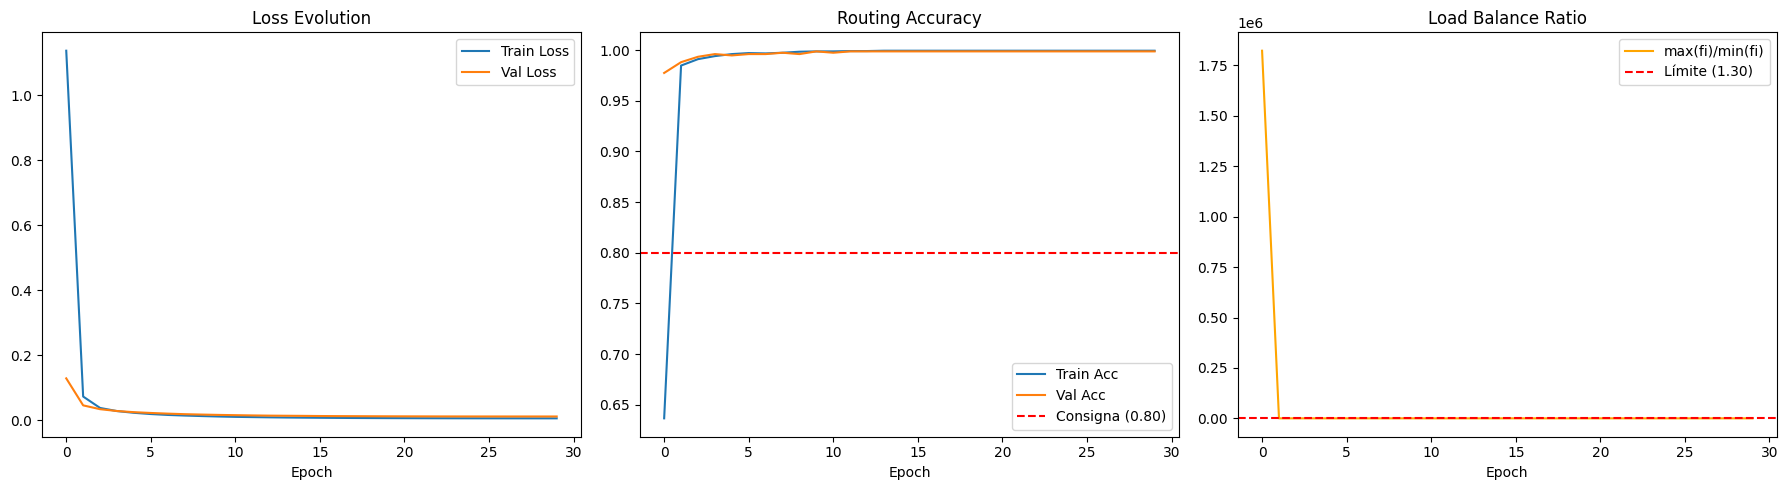

Figura 1 guardada.


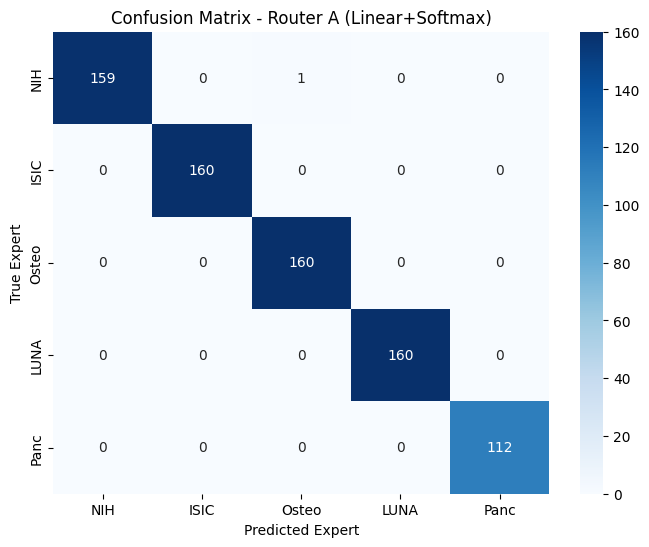

Figura 2 guardada.


In [22]:
# Fase 8: Figuras para el Reporte Técnico
import matplotlib.pyplot as plt
import seaborn as sns

fig_dir = os.path.join(ROUTER_WEIGHTS_DIR, "figures")

# Fig 1: Curvas de Entrenamiento
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Evolution"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].axhline(y=0.80, color="red", linestyle="--", label="Consigna (0.80)")
axes[1].set_title("Routing Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(history["balance"], label="max(fi)/min(fi)", color="orange")
axes[2].axhline(y=1.30, color="red", linestyle="--", label="Límite (1.30)")
axes[2].set_title("Load Balance Ratio"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "router_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figura 1 guardada.")

# Fig 2: Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NIH","ISIC","Osteo","LUNA","Panc"],
            yticklabels=["NIH","ISIC","Osteo","LUNA","Panc"])
plt.title("Confusion Matrix - Router A (Linear+Softmax)")
plt.xlabel("Predicted Expert"); plt.ylabel("True Expert")
plt.savefig(os.path.join(fig_dir, "router_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figura 2 guardada.")


In [23]:
# Fase 9: Ablation Study (Mecanismos B, C, D) sobre mismos embeddings
!pip install -q faiss-cpu
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
import faiss

# Cargar directamente embeddings guardados en Fase 6
_tr = np.load(Z_TRAIN_PATH); Z_train, y_train = _tr["Z"], _tr["y"]
_vl = np.load(Z_VAL_PATH);   Z_val,   y_val   = _vl["Z"], _vl["y"]
print(f"Embeddings cargados: Z_train={Z_train.shape} Z_val={Z_val.shape}")

results = {}

# B) GMM
gmm = GaussianMixture(n_components=5, covariance_type="full", random_state=42)
gmm.fit(Z_train, y_train)  # Supervisado: asignamos componente = expert_id
preds_gmm = gmm.predict(Z_val)
acc_gmm = accuracy_score(y_val, preds_gmm)
f1_gmm = f1_score(y_val, preds_gmm, average="macro")
results["GMM"] = {"acc": acc_gmm, "f1": f1_gmm}
print(f"[B] GMM:        Acc={acc_gmm:.4f}  F1={f1_gmm:.4f}")

# C) Naive Bayes
nb_model = GaussianNB()
nb_model.fit(Z_train, y_train)
preds_nb = nb_model.predict(Z_val)
acc_nb = accuracy_score(y_val, preds_nb)
f1_nb = f1_score(y_val, preds_nb, average="macro")
results["NaiveBayes"] = {"acc": acc_nb, "f1": f1_nb}
print(f"[C] NaiveBayes: Acc={acc_nb:.4f}  F1={f1_nb:.4f}")

# D) k-NN con FAISS + PCA
pca = PCA(n_components=32, random_state=42)
Z_train_pca = pca.fit_transform(Z_train).astype("float32")
Z_val_pca = pca.transform(Z_val).astype("float32")

index = faiss.IndexFlatL2(32)
index.add(Z_train_pca)
D, I = index.search(Z_val_pca, k=5)
# Voto mayoritario
from scipy import stats
preds_knn = stats.mode(y_train[I], axis=1, keepdims=False).mode
acc_knn = accuracy_score(y_val, preds_knn)
f1_knn = f1_score(y_val, preds_knn, average="macro")
results["kNN_FAISS"] = {"acc": acc_knn, "f1": f1_knn}
print(f"[D] k-NN FAISS: Acc={acc_knn:.4f}  F1={f1_knn:.4f}")

# Tabla comparativa
print("\n" + "="*60)
print("ABLATION STUDY - COMPARATIVA DE ROUTERS")
print("="*60)
print(f"  A) Linear+Softmax: Acc={val_acc:.4f}  F1={val_f1:.4f}")
print(f"  B) GMM:            Acc={acc_gmm:.4f}  F1={f1_gmm:.4f}")
print(f"  C) NaiveBayes:     Acc={acc_nb:.4f}  F1={f1_nb:.4f}")
print(f"  D) k-NN FAISS:     Acc={acc_knn:.4f}  F1={f1_knn:.4f}")

# Guardar resultados
results["Linear_Softmax"] = {"acc": val_acc, "f1": val_f1}
with open(os.path.join(ROUTER_WEIGHTS_DIR, "metrics", "ablation_results.json"), "w") as f:
    json.dump(results, f, indent=2)
print("\nResultados del Ablation guardados en Drive.")


Embeddings cargados: Z_train=(3005, 192) Z_val=(752, 192)
[B] GMM:        Acc=0.2141  F1=0.1984
[C] NaiveBayes: Acc=0.9960  F1=0.9962
[D] k-NN FAISS: Acc=1.0000  F1=1.0000

ABLATION STUDY - COMPARATIVA DE ROUTERS
  A) Linear+Softmax: Acc=0.9987  F1=0.9987
  B) GMM:            Acc=0.2141  F1=0.1984
  C) NaiveBayes:     Acc=0.9960  F1=0.9962
  D) k-NN FAISS:     Acc=1.0000  F1=1.0000

Resultados del Ablation guardados en Drive.


### Fase 4: DataLoader Mixto y Switchable Patch Embed (Técnica SPE)\n
Este módulo procesa tensores 2D y 3D en un mismo batch sin colapsar por diferencias dimensionales, y los prepara unificadamente para los 12 bloques del Router.

In [ ]:
from monai.networks.blocks import PatchEmbed
import torch
import torch.nn as nn
from einops import rearrange

class SwitchablePatchEmbed(nn.Module):
    """TÉCNICA GANADORA: Switchable / Unified Patch Embedding (SPE de USST/UniMiSS)"""
    def __init__(self, embed_dim=192, 
                 patch_size_2d=16, 
                 patch_size_3d=8,
                 in_channels=3):          # Recomendado: 3 para compatibilidad con timm
        super().__init__()
        self.embed_dim = embed_dim
        
        # Un solo módulo que switcha según dimensionalidad
        self.patch_embed_2d = PatchEmbed(
            spatial_dims=2,
            in_channels=in_channels,
            patch_size=patch_size_2d,
            embed_dim=embed_dim
        )
        self.patch_embed_3d = PatchEmbed(
            spatial_dims=3,
            in_channels=1,                    # CT siempre 1 canal
            patch_size=patch_size_3d,
            embed_dim=embed_dim
        )
        
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        # 513 = 512 (3D) + 1 CLS  (máximo posible)
        self.pos_embed = nn.Parameter(torch.randn(1, 513, embed_dim))

    def forward(self, batch_tensors):
        batch_size = len(batch_tensors)
        tokens_list = []
        
        for sample in batch_tensors:
            sample = sample.unsqueeze(0)  # [1, C, ...]
            
            if sample.ndim == 5:  # 3D: [1, 1, D, H, W]
                patch_tokens = self.patch_embed_3d(sample)   # [1, 512, 192]
            else:                 # 2D: [1, 3, H, W]
                patch_tokens = self.patch_embed_2d(sample)   # [1, 196, 192]
            
            tokens_list.append(patch_tokens.squeeze(0))
        
        # Paso H: Padding de secuencia
        padded_tokens = torch.nn.utils.rnn.pad_sequence(tokens_list, batch_first=True)
        
        # Máscara de atención (para ignorar padding en los bloques Transformer)
        seq_lengths = torch.tensor([t.size(0) for t in tokens_list], device=padded_tokens.device)
        max_len = padded_tokens.size(1)
        mask = torch.arange(max_len, device=padded_tokens.device)[None, :] < seq_lengths[:, None]
        
        # Paso I: CLS + Positional
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        final_tokens = torch.cat((cls_tokens, padded_tokens), dim=1)  # [B, 1+max_len, 192]
        
        # Máscara actualizada (CLS siempre válido)
        cls_mask = torch.ones(batch_size, 1, dtype=torch.bool, device=mask.device)
        final_mask = torch.cat((cls_mask, mask), dim=1)
        
        # Positional embeddings (cortamos al tamaño real del batch)
        final_tokens = final_tokens + self.pos_embed[:, :final_tokens.size(1), :]
        
        return final_tokens, final_mask  # listo para los 12 bloques de Self-Attention


In [ ]:
# Prueba rápida de SwitchablePatchEmbed con tensores dummy
model = SwitchablePatchEmbed()
dummy_tensors = [
    torch.randn(3, 224, 224),      # 2D
    torch.randn(1, 64, 64, 64),    # 3D
    torch.randn(3, 224, 224)       # 2D
]
final_tokens, final_mask = model(dummy_tensors)
print("Shape de los tokens (B, seq_len, 192):", final_tokens.shape)   # esperado: [3, 513, 192]
print("Shape de la máscara de atención:", final_mask.shape)     # esperado: [3, 513]


In [ ]:
from torch.utils.data import Dataset, DataLoader

class MixedMedicalDataset(Dataset):
    def __init__(self, file_list, dataset_ids, preprocessor):
        """
        file_list: lista de rutas absolutas a los archivos.
        dataset_ids: lista de enteros que mapea cada archivo a su ID de dataset.
        preprocessor: instancia de AdaptivePreprocessor.
        """
        self.file_list = file_list
        self.dataset_ids = dataset_ids
        self.preprocessor = preprocessor
        
    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        tensor = self.preprocessor(self.file_list[idx])
        return tensor, self.dataset_ids[idx]

def mixed_collate_fn(batch):
    """
    Retorna los tensores crudos como lista para evitar que DataLoader
    intente apilar (torch.stack) tensores 2D y 3D mezclados.
    """
    tensors = [b[0] for b in batch]           # lista de tensores crudos de distintas formas
    dataset_ids = torch.tensor([b[1] for b in batch], dtype=torch.long)
    return tensors, dataset_ids

def build_router_dataloader(roots, preprocessor, batch_size=8, num_workers=2):
    """
    Construye el DataLoader Mixto.
    roots: dict con {dataset_name: (path, dataset_id)}
    """
    all_files, all_ids = [], []
    for name, (path, did) in roots.items():
        files = scan_dataset_files(path)  # Lógica del notebook superior
        all_files.extend(files)
        all_ids.extend([did] * len(files))
    
    dataset = MixedMedicalDataset(all_files, all_ids, preprocessor)
    sampler = torch.utils.data.RandomSampler(dataset)
    
    loader = DataLoader(dataset, batch_size=batch_size, sampler=sampler, 
                        collate_fn=mixed_collate_fn, num_workers=num_workers)
    return loader


### Fase 5: VisionRouter Completo y Extracción de Características (I$→$M)\n
En esta etapa, el Transformer procesa las secuencias de parches y extrae el **Token CLS Final**, el cual se guarda en disco para el estudio de ablación posterior.

In [ ]:
class VisionRouter(nn.Module):
    """
    MODELO COMPLETO DEL ROUTER (Pasos I-M)
    Unifica SwitchablePatchEmbed con 12 bloques de Transformer para obtener el vector 1x192.
    """
    def __init__(self, embed_dim=192, num_heads=3, num_layers=12, num_experts=5):
        super().__init__()
        self.embedding = SwitchablePatchEmbed(embed_dim=embed_dim)
        
        # J: 12 Bloques de Self-Attention
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dim_feedforward=embed_dim*4,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # M: Capa Lineal del Router (Ablación 1: Linear)
        self.router_head = nn.Linear(embed_dim, num_experts)

    def forward(self, batch_tensors):
        """Flujo completo de inferencia del Router"""
        # A-I: Embedding + CLS + Positional
        x, mask = self.embedding(batch_tensors)
        
        # J: Transformer Blocks (invertimos mask para PyTorch: True=ignorar)
        padding_mask = ~mask 
        x = self.transformer(x, src_key_padding_mask=padding_mask)
        
        # K, L: Extracción del CLS Final (Posición 0)
        cls_final = x[:, 0, :] # [B, 192]
        
        # M: Probabilidades del Router
        logits = self.router_head(cls_final)
        return logits, cls_final


In [ ]:
def extract_and_save_cls_features(dataloader, model, save_path):
    """
    Extrae los vectores 1x192 de todo el dataset y los guarda en disco.
    Esto permite hacer los estudios de ablación (paso K) sin re-entrenar el ViT.
    """
    model.eval()
    all_features = []
    all_labels = []
    
    print(f"Iniciando extracción de características en {save_path}...")
    with torch.no_grad():
        for i, (tensors, ids) in enumerate(dataloader):
            # Los tensores se pasan como lista (mixed_collate_fn)
            _, cls_features = model(tensors)
            all_features.append(cls_features.cpu())
            all_labels.append(ids.cpu())
            if (i+1) % 10 == 0: print(f"Procesados {i+1} batches...")
            
    # Concatenar y guardar
    features_tensor = torch.cat(all_features, dim=0)
    labels_tensor = torch.cat(all_labels, dim=0)
    
    torch.save({
        'features': features_tensor,
        'dataset_ids': labels_tensor
    }, save_path)
    print(f"Extracción completada. Guardado en: {save_path}")

# Ejemplo de uso (ejecutar solo cuando los datasets estén listos)
# FEATURE_SAVE_PATH = '/content/drive/MyDrive/PROYECTO_MOE_VISION/03_CLS_Features/router_features_v1.pth'
# os.makedirs(os.path.dirname(FEATURE_SAVE_PATH), exist_ok=True)
# extract_and_save_cls_features(loader, model, FEATURE_SAVE_PATH)


In [ ]:
### Fase 5: Estudio de Ablación (Routing Mechanisms)
"""
Una vez guardados los CLS en disco, podemos comparar qué clasifica mejor 
el flujo hacia los expertos:
1. Linear (Capa densa)
2. GMM (Gaussian Mixture Model)
3. Naive Bayes
4. k-NN
"""
def train_ablation_router(cls_features, labels, method='linear'):
    if method == 'linear':
        # Implementar entrenamiento de capa lineal
        pass
    elif method == 'knn':
        # Usar sklearn.neighbors.KNeighborsClassifier
        pass
    print(f"Entrenando ruteador con método: {method}")
